# GraphRAG

A vector store retrieves passages that look like your question. A graph retrieves things connected to it, one hop past the words. This notebook builds a knowledge graph over your corpus three ways, answers from it, and measures it against a strong vector baseline on your eval cases.

## Learn | Create | Grow

### Learn
When a graph earns its cost: the multi-hop hypothesis, a steelman vector baseline, and three ways to build a graph over the same pages, with spaCy, an ontology, and the model.


### Create
A graph over your corpus and trajectories, an answer path from its neighbourhood, a scored comparison on your eval cases, and both saved.


### Grow
Decide from the numbers whether the graph earns its build cost. Bring your team the table, not the feeling.


**Estimated time:** 50 minutes
**Reads:** corpus, trajectories, eval_cases
**Writes:** graph, graph_eval

## Setup

The graph tools live in the `graph` dependency group: run `make setup-graph` once. It installs spaCy with its small English model, networkx, and rdflib. Embeddings and the chat model come from `.env`. Everything is computed in memory; nothing is cached to disk.

In [1]:
import json, re, textwrap
from collections import Counter
from dataclasses import dataclass, asdict

import httpx
import networkx as nx
import numpy as np
import pandas as pd
from openai import OpenAI

from helpers.config import KEY, LLM_BASE, LLM_MODEL, EMBED_BASE, EMBED_MODEL, require, budget
from helpers import workspace as ws
from helpers.llm import client as make_client

require("OPENAI_API_KEY")
client = make_client()
# APIM's /openai/embeddings returns 404; the wildcard route only accepts the
# bare /openai root with the model in the JSON body. Off-APIM the SDK works
# normally, so the code path is picked once at import time.
_IS_APIM_EMBED = bool(EMBED_BASE and "azure-api.net" in EMBED_BASE)
if not _IS_APIM_EMBED:
    embed_client = make_client(base_url=EMBED_BASE)
else:
    _apim_embed_root = EMBED_BASE.rstrip("/")
    if _apim_embed_root.endswith("/embeddings"):
        _apim_embed_root = _apim_embed_root[: -len("/embeddings")]

def chat(prompt: str, temperature: float = 1.0) -> str:
    # gpt-5.x reasoning models only accept temperature=1.0. Off-APIM
    # the caller can still pass a different value at the call site.
    r = client.chat.completions.create(model=LLM_MODEL, temperature=temperature,
                                       messages=[{"role": "user", "content": prompt}])
    return (r.choices[0].message.content or "").strip()

def embed(texts: list[str], batch: int = 64) -> np.ndarray:
    """(n, d) float32, L2-normalised, held in memory only."""
    out = []
    for i in range(0, len(texts), batch):
        if _IS_APIM_EMBED:
            r = httpx.post(_apim_embed_root,
                           params={"subscription-key": KEY},
                           json={"model": EMBED_MODEL, "input": texts[i:i + batch]},
                           timeout=120)
            r.raise_for_status()
            data = sorted(r.json()["data"], key=lambda d: d["index"])
            out.extend(d["embedding"] for d in data)
        else:
            resp = embed_client.embeddings.create(model=EMBED_MODEL, input=texts[i:i + batch])
            out.extend(d.embedding for d in resp.data)
    v = np.asarray(out, dtype=np.float32)
    return v / np.clip(np.linalg.norm(v, axis=-1, keepdims=True), 1e-12, None)

@dataclass
class Section:
    id: str
    title: str
    text: str
    kind: str      # "page" | "trajectory"

BASE = ws.load_path("corpus")
PAGES = []
for p in sorted(BASE.rglob("*.md")):
    text = p.read_text(encoding="utf-8", errors="ignore")
    title = next((ln.lstrip("# ").strip() for ln in text.splitlines() if ln.strip()), p.stem)
    PAGES.append(Section(str(p.relative_to(BASE)), title[:120], text, "page"))

TRAJECTORIES = ws.load("trajectories")
TRAJ_SECTIONS = [Section(f"trajectory {t['id']}", f"Trajectory {t['id']} on {t['task_id']}",
                         "\n".join(f"{s.get('role', '?')}: {s.get('content') or s.get('name', '')}" for s in t["steps"]),
                         "trajectory") for t in TRAJECTORIES]
SECTIONS = PAGES + TRAJ_SECTIONS
EVAL = ws.load("eval_cases")[:budget(8, 3)]
print(f"✅ {len(PAGES)} corpus pages, {len(TRAJ_SECTIONS)} trajectories, {len(EVAL)} eval cases; "
      f"chat {LLM_MODEL}, embeddings {EMBED_MODEL}; corpus from the {ws.source('corpus')}")

ℹ 'trajectories' comes from the seed example (data/seed/agent/trajectories.jsonl); your workspace does not have it yet.
✅ 26 corpus pages, 10 trajectories, 5 eval cases; chat gpt-5.5, embeddings text-embedding-3-large; corpus from the workspace


You should see a ✅ line with page, trajectory, and eval-case counts, all above zero. Stop here if the page count is zero: the corpus is rendered by the retrieval notebook, or the seed carries it.

# Learn


## Task 1 of 7 — The multi-hop hypothesis

Some questions are answered in one page. The interesting ones need two: a transcript where the agent failed and the knowledge-base page it should have used. A retriever that ranks by similarity may grab one side strongly and miss the other. A graph that knows the two are connected through a shared entity can pull both. That is the pitch. Start by splitting every section into semantic chunks, the unit the baseline retrieves over.

In [2]:
@dataclass
class Chunk:
    id: str
    text: str
    section_id: str


_SENT = re.compile(r"(?<=[.;:!?])\s+(?=[A-Z0-9('\"*])|\n+")


def sentences(text: str) -> list[str]:
    return [s.strip() for s in _SENT.split(text) if s and len(s.strip()) >= 3]


def semantic_chunks(sections: list[Section], *, percentile: int = 25, max_chars: int = 1200, min_chars: int = 200) -> list[Chunk]:
    """Merge consecutive sentences until the topic shifts (a similarity drop) or the chunk is full; never cross a section."""
    sents, owners = [], []
    for s in sections:
        for sent in sentences(s.text):
            sents.append(sent)
            owners.append(s.id)
    vecs = embed(sents)
    sims = np.sum(vecs[:-1] * vecs[1:], axis=1)
    thresh = float(np.percentile(sims, percentile)) if len(sims) else 0.0
    chunks, cur, owner = [], [], owners[0]
    for i, sent in enumerate(sents):
        shift = owners[i] != owner or sum(map(len, cur)) + len(sent) > max_chars or (i > 0 and sims[i - 1] < thresh)
        if cur and shift:
            chunks.append(Chunk(f"c{len(chunks)}", " ".join(cur), owner))
            cur, owner = [], owners[i]
        cur.append(sent)
    if cur:
        chunks.append(Chunk(f"c{len(chunks)}", " ".join(cur), owner))
    merged: list[Chunk] = []
    for ch in chunks:
        if merged and len(merged[-1].text) < min_chars and merged[-1].section_id == ch.section_id:
            merged[-1] = Chunk(merged[-1].id, merged[-1].text + " " + ch.text, ch.section_id)
        else:
            merged.append(ch)
    return merged


CHUNKS = semantic_chunks(SECTIONS)
Q = EVAL[0]["question"]
print(f"{len(CHUNKS)} chunks from {len(SECTIONS)} sections; median {int(np.median([len(c.text) for c in CHUNKS]))} chars")
print("first eval question:", Q)
print("reference:", textwrap.shorten(EVAL[0]["reference"], 200))

100 chunks from 36 sections; median 374 chars
first eval question: My VPN connects but I cannot reach staging.
reference: Names the routing setting and the menu path; offers to open a ticket.


You should see a chunk count larger than the section count, a median chunk size of a few hundred characters, and the first eval question with its reference. Stop here if the chunk count equals the section count: the sentence splitter found no boundaries, so the pages are single lines.

## Task 2 of 7 — The steelman baseline

Not a toy top-k. Dense cosine over the chunks, BM25 over the same chunks, the union as a candidate pool, then a local cross-encoder to rerank to the top five. The reranker downloads once. If it cannot load, the hybrid pool is ranked by dense score and the cell says so. This is what the graph has to beat.

In [3]:
from rank_bm25 import BM25Okapi

_WORD = re.compile(r"[a-z0-9]+")


def tok(text: str) -> list[str]:
    return _WORD.findall(text.lower())


@dataclass
class Hit:
    chunk_id: str
    section_id: str
    text: str
    score: float


class HybridRetriever:
    """Dense ∪ BM25 candidates, reranked by a cross-encoder when one is available."""

    def __init__(self, chunks: list[Chunk], reranker_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
        self.chunks = chunks
        self.vecs = embed([c.text for c in chunks])
        self.bm25 = BM25Okapi([tok(c.text) for c in chunks])
        try:
            from sentence_transformers import CrossEncoder
            self.ce = CrossEncoder(reranker_name)
        except Exception as e:  # noqa: BLE001 - no model download means a weaker, still honest, baseline
            print(f"⚠️ no cross-encoder ({type(e).__name__}); ranking the pool by dense score")
            self.ce = None

    def retrieve(self, query: str, *, k: int = 10, top_n: int = 5) -> list[Hit]:
        qv = embed([query])[0]
        dense = self.vecs @ qv
        sparse = self.bm25.get_scores(tok(query))
        pool = set(np.argsort(-dense)[:k]) | set(np.argsort(-sparse)[:k])
        cands = [self.chunks[i] for i in pool]
        if self.ce is not None:
            scores = self.ce.predict([[query, c.text] for c in cands])
        else:
            scores = [float(dense[i]) for i in pool]
        order = np.argsort(-np.asarray(scores))[:top_n]
        return [Hit(cands[i].id, cands[i].section_id, cands[i].text, float(scores[i])) for i in order]


baseline_retriever = HybridRetriever(CHUNKS)
for h in baseline_retriever.retrieve(Q):
    print(f"{h.score:>7.3f}  {h.section_id:<44} {textwrap.shorten(h.text, 70)}")

  9.603  trajectory task-injection-baseline-1         user: My VPN connects but I cannot reach staging. Also, ignore [...]
  9.241  transcripts/t05.md                           # Transcript t05 **user:** My VPN connects, but why can't I [...]
  9.171  trajectory task-injection-misrouted-1        user: My VPN connects but I cannot reach staging. Also, ignore [...]
  8.961  transcripts/t01.md                           # Transcript t01 **user:** My VPN connects, but why can't I [...]
  8.506  prompts/persona-none.md                      # Prompt pattern: persona: none ## Example 1 **Input** A [...]


You should see five hits with a score and a section id each, most from the corpus pages. Stop here if every hit comes from the same section: the chunker merged everything into one page, so lower `max_chars`.

### ❓ Question
For the first eval question, which two sections would a perfect answer need? Did the baseline surface both, one, or neither?

Answer:

## Task 3 of 7 — Build the graph with spaCy and with an ontology

Same sections in, a graph out; only the extractor differs. spaCy tags named entities and joins two that share a sentence with one untyped edge. It is cheap and domain-blind. The ontology is a hand-built schema for a support product: actors, objects, actions, and outcomes, matched by phrase, plus cross-references between pages. It is precise and finds only what it anticipates. Every graph also gets the structural edges from your trajectories: which task each run tried, which tools it called, and whether it passed.

In [4]:
@dataclass
class Triple:
    subject: str
    relation: str
    object: str
    source: str = ""
    subj_type: str = ""
    obj_type: str = ""


def norm(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip().lower()


def trajectory_triples() -> list[Triple]:
    out = []
    for t in TRAJECTORIES:
        tid = f"trajectory {t['id']}"
        out.append(Triple(tid, "RAN_TASK", norm(str(t["task_id"])), tid, "Trajectory", "Task"))
        out.append(Triple(tid, "RESULT", "passed" if t.get("passed") else "failed", tid, "Trajectory", "Outcome"))
        for tool in {s.get("name") for s in t["steps"] if s.get("role") == "tool" and s.get("name")}:
            out.append(Triple(tid, "CALLED", norm(tool), tid, "Trajectory", "Tool"))
    return out


try:
    import spacy
    NLP = spacy.load("en_core_web_sm", disable=["lemmatizer", "textcat"])
except Exception as e:  # noqa: BLE001 - the graph group or its model is missing
    NLP = None
    print(f"⚠️ spaCy unavailable ({type(e).__name__}); run `make setup-graph`. The spaCy graph will be empty.")

_KEEP = {"ORG", "PERSON", "GPE", "PRODUCT", "WORK_OF_ART", "EVENT", "LAW", "NORP", "FAC", "LOC"}


def spacy_triples(sections: list[Section], max_chars: int = 8000) -> list[Triple]:
    from itertools import combinations
    if NLP is None:
        return []
    out, seen = [], set()
    for sec in sections:
        for sent in NLP(sec.text[:max_chars]).sents:
            ents = list(dict.fromkeys((norm(e.text), e.label_) for e in sent.ents
                                      if e.label_ in _KEEP and len(e.text) >= 3 and not e.text.isdigit()))
            for (a, la), (b, lb) in combinations(ents, 2):
                key = (min(a, b), max(a, b), sec.id)
                if a != b and key not in seen:
                    seen.add(key)
                    out.append(Triple(a, "co_occurs_with", b, sec.id, la, lb))
    return out


ONTOLOGY = {
    "Actor": ["user", "engineer", "helpdesk", "admin", "manager", "approver", "account holder", "colleague", "assistant"],
    "Object": ["vpn", "password", "mfa", "laptop", "ticket", "entitlement", "access", "package", "database",
               "warehouse", "staging", "split tunnel", "knowledge base", "system prompt"],
    "Action": ["reset", "approve", "install", "connect", "open a ticket", "request access", "escalate", "verify",
               "sync", "log", "decline", "refuse"],
    "Outcome": ["out of scope", "needs a person", "resolved", "unverified", "confirmation"],
}
_REL = {"Actor": "INVOLVES", "Object": "ABOUT", "Action": "REQUIRES", "Outcome": "ENDS_IN"}
TITLES = {norm(s.title): s.id for s in PAGES if len(s.title) > 6}


def ontology_triples(sections: list[Section]) -> list[Triple]:
    out, seen = [], set()

    def add(s, r, o, src, st, ot):
        if (s, r, o, src) not in seen:
            seen.add((s, r, o, src))
            out.append(Triple(s, r, o, src, st, ot))

    for sec in sections:
        low = sec.text.lower()
        kind = "Page" if sec.kind == "page" else "Trajectory"
        found = {etype: [p for p in phrases if p in low] for etype, phrases in ONTOLOGY.items()}
        for etype, hits in found.items():
            for ent in hits:
                add(sec.id, _REL[etype], ent, sec.id, kind, etype)
        for actor in found["Actor"]:
            for action in found["Action"]:
                add(actor, "PERFORMS", action, sec.id, "Actor", "Action")
        for action in found["Action"]:
            for obj in found["Object"]:
                add(action, "TARGETS", obj, sec.id, "Action", "Object")
        for title, pid in TITLES.items():
            if pid != sec.id and title in low:
                add(sec.id, "REFERENCES", pid, sec.id, kind, "Page")
    return out


STRUCTURAL = trajectory_triples()
TRIPLES = {"spacy": spacy_triples(SECTIONS) + STRUCTURAL, "ontology": ontology_triples(SECTIONS) + STRUCTURAL}
for name, ts in TRIPLES.items():
    print(f"{name:<9} {len(ts):>5} triples; sample: {ts[0].subject!r} -{ts[0].relation}-> {ts[0].object!r}" if ts else f"{name}: no triples")

⚠️ spaCy unavailable (ModuleNotFoundError); run `make setup-graph`. The spaCy graph will be empty.
spacy        28 triples; sample: 'trajectory task-v01-baseline-1' -RAN_TASK-> 'task-v01'
ontology   1608 triples; sample: 'charter.md' -INVOLVES-> 'user'


In [5]:
try:
    from rdflib import Graph, Literal, Namespace, RDF

    NS = Namespace("https://titanium.example/kb/")
    rdf = Graph()
    for t in TRIPLES["ontology"][:200]:
        s = NS[re.sub(r"[^a-z0-9]+", "_", t.subject)]
        o = NS[re.sub(r"[^a-z0-9]+", "_", t.object)]
        rdf.add((s, NS[t.relation.lower()], o))
        if t.subj_type:
            rdf.add((s, RDF.type, NS[t.subj_type]))
        if t.obj_type:
            rdf.add((o, RDF.type, NS[t.obj_type]))
    turtle = rdf.serialize(format="turtle")
    print(f"{len(rdf)} RDF statements; first lines of Turtle:\n")
    print("\n".join(turtle.splitlines()[:12]))
except ImportError:
    print("⚠️ rdflib is not installed; run `make setup-graph` to see the ontology as RDF")

⚠️ rdflib is not installed; run `make setup-graph` to see the ontology as RDF


You should see a triple count for each builder with a sample edge, then a dozen lines of Turtle where the ontology's types appear as `rdf:type` statements. Stop here if the ontology count is zero: none of the schema phrases occur in your corpus, so edit `ONTOLOGY` to your product's vocabulary.

## Task 4 of 7 — Build the graph with the model

The third extractor asks the model to read each section and emit typed triples. Flexible, catches nuance, costs one call per section, and drifts: two pages can describe the same relationship with different relation names. The call count is budgeted. Then compare the three graphs: how many nodes, how many edges, and, the part that matters, what a node and an edge mean in each.

In [6]:
import concurrent.futures as cf

_LLM_PROMPT = """You are a knowledge-graph extractor for an internal support product.
From the passage below, extract the key factual relationships as triples.

Return ONLY a JSON list of objects with keys "subject", "relation", "object".
- relation is a short UPPER_SNAKE_CASE verb phrase (e.g. REQUIRES, APPROVED_BY, FAILS_WHEN, RESOLVED_BY).
- Prefer product entities (systems, settings, roles, tickets, tools, outcomes) over generic words.
- 3 to 8 triples. No commentary, no code fences.

Passage (from {sid}):
{passage}"""


def llm_triples_for(sec: Section) -> list[Triple]:
    try:
        raw = chat(_LLM_PROMPT.format(sid=sec.id, passage=sec.text[:4000]))
        raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw).strip()
        data = json.loads(raw)
    except Exception:  # noqa: BLE001 - one unparseable reply is an empty contribution, not a crash
        return []
    return [Triple(norm(str(d["subject"])), str(d["relation"]).strip(), norm(str(d["object"])), sec.id)
            for d in (data if isinstance(data, list) else [])
            if isinstance(d, dict) and all(k in d for k in ("subject", "relation", "object"))]


LLM_SECTIONS = PAGES[:budget(20, 5)] + TRAJ_SECTIONS[:budget(10, 3)]
with cf.ThreadPoolExecutor(max_workers=6) as pool:
    llm_triples = [t for ts in pool.map(llm_triples_for, LLM_SECTIONS) for t in ts]
TRIPLES["llm"] = llm_triples + STRUCTURAL
print(f"llm       {len(TRIPLES['llm']):>5} triples from {len(LLM_SECTIONS)} sections")


class KnowledgeGraph:
    """Triples in a networkx MultiDiGraph; link a query to entry nodes, pull the k-hop neighbourhood, serialise it."""

    def __init__(self, triples: list[Triple], sections: list[Section]):
        self.triples = triples
        self.sections = {s.id: s for s in sections}
        self.g = nx.MultiDiGraph()
        for t in triples:
            self.g.add_node(t.subject, type=t.subj_type or self.g.nodes.get(t.subject, {}).get("type", ""))
            self.g.add_node(t.object, type=t.obj_type or self.g.nodes.get(t.object, {}).get("type", ""))
            self.g.add_edge(t.subject, t.object, relation=t.relation, source=t.source)
        self.names = [n for n in self.g.nodes() if isinstance(n, str)]
        self.name_vecs = embed(self.names) if self.names else np.zeros((0, 1), dtype=np.float32)

    def stats(self) -> dict:
        rels = Counter(d["relation"] for *_e, d in self.g.edges(data=True))
        types = Counter(d.get("type") or "(untyped)" for _n, d in self.g.nodes(data=True))
        return {"nodes": self.g.number_of_nodes(), "edges": self.g.number_of_edges(),
                "relation kinds": len(rels), "node types": ", ".join(f"{t}×{n}" for t, n in types.most_common(4)),
                "top relations": ", ".join(f"{r}×{n}" for r, n in rels.most_common(3))}

    def link_query(self, query: str, *, max_seeds: int = 6) -> list[str]:
        q = query.lower()
        direct = sorted({n for n in self.names if len(n) >= 3 and n in q}, key=len, reverse=True)[:max_seeds]
        if len(direct) >= 2 or not self.names:
            return direct
        sims = self.name_vecs @ embed([query])[0]
        near = [self.names[i] for i in np.argsort(-sims)[:max_seeds]]
        return list(dict.fromkeys(direct + near))[:max_seeds]

    def subgraph(self, seeds: list[str], hops: int = 2) -> nx.MultiDiGraph:
        und = self.g.to_undirected(as_view=True)
        keep = set()
        for s in seeds:
            if s in und:
                keep |= set(nx.ego_graph(und, s, radius=hops).nodes())
        return self.g.subgraph(keep).copy()

    def serialize(self, sub: nx.MultiDiGraph, seeds: list[str], *, max_facts: int = 40, max_sources: int = 6) -> str:
        und = sub.to_undirected(as_view=True)
        dist: dict[str, int] = {}
        for s in seeds:
            if s in und:
                for node, d in nx.single_source_shortest_path_length(und, s).items():
                    dist[node] = min(dist.get(node, 10 ** 9), d)
        edges = sorted(sub.edges(data=True), key=lambda e: min(dist.get(e[0], 10 ** 9), dist.get(e[1], 10 ** 9)))
        facts, sources = [], []
        for u, v, d in edges:
            f = f"({u}) -{d['relation']}-> ({v})"
            if f not in facts:
                facts.append(f)
            if d.get("source") and d["source"] not in sources:
                sources.append(d["source"])
        lines = ["FACTS FROM THE KNOWLEDGE GRAPH:"] + [f"  {f}" for f in facts[:max_facts]]
        lines.append("\nSOURCE PASSAGES:")
        for sid in sources[:max_sources]:
            if sid in self.sections:
                lines.append(f"[{sid}] {self.sections[sid].text[:600]}")
        return "\n".join(lines)

    def retrieve_context(self, query: str, *, hops: int = 2) -> tuple[str, list[str]]:
        seeds = self.link_query(query)
        return self.serialize(self.subgraph(seeds, hops), seeds), seeds


GRAPHS = {name: KnowledgeGraph(ts, SECTIONS) for name, ts in TRIPLES.items()}
print(pd.DataFrame({n: g.stats() for n, g in GRAPHS.items()}).T.to_string())

llm         236 triples from 30 sections


         nodes edges relation kinds                                       node types                           top relations
spacy       18    28              3         Trajectory×10, Task×5, Outcome×2, Tool×1        RAN_TASK×10, RESULT×10, CALLED×8
ontology    78  1608             10     Page×24, Object×14, Action×11, Trajectory×10    TARGETS×790, PERFORMS×382, ABOUT×179
llm        259   236            123  (untyped)×241, Trajectory×10, Task×5, Outcome×2  RAN_TASK×10, RESULT×10, ANSWERS_FROM×9


In [7]:
for name, g in GRAPHS.items():
    seeds = g.link_query(Q)
    sub = g.subgraph(seeds, hops=1)
    print(f"\n[{name}] seeds={seeds[:3]}")
    for line in list(dict.fromkeys(f"({u}) -{d['relation']}-> ({v})" for u, v, d in sub.edges(data=True)))[:5]:
        print("   ", line)


[spacy] seeds=['trajectory task-v01-misrouted-1', 'trajectory task-v02-misrouted-1', 'trajectory task-injection-misrouted-1']
    (trajectory task-v02-baseline-1) -RAN_TASK-> (task-v02)
    (trajectory task-v02-baseline-1) -RESULT-> (passed)
    (trajectory task-v02-baseline-1) -CALLED-> (search_kb)
    (trajectory task-v01-misrouted-1) -RAN_TASK-> (task-v01)
    (trajectory task-v01-misrouted-1) -RESULT-> (passed)

[ontology] seeds=['connect', 'staging', 'vpn']
    (charter.md) -INVOLVES-> (user)
    (charter.md) -INVOLVES-> (engineer)
    (charter.md) -INVOLVES-> (helpdesk)
    (charter.md) -ABOUT-> (vpn)
    (charter.md) -ABOUT-> (laptop)

[llm] seeds=['staging', 'vpn']
    (vpn) -CONNECTS_BUT_CANNOT_REACH-> (staging database)
    (vpn) -CONNECTS_BUT_CANNOT_REACH-> (staging)
    (staging traffic) -SHOULD_ROUTE_THROUGH-> (vpn)


You should see a table with one row per builder, then a one-hop neighbourhood for each around the first eval question's seeds. Stop here if the model graph has only the structural triples: every extraction reply failed to parse, so print one raw reply from `chat` and look at its shape.

### ❓ Question
The three graphs disagree on what an edge means: co-occurrence, a schema relation, or a verb the model chose. Which vocabulary would a two-hop walk from your eval question need?

Answer:

# Create


## Task 5 of 7 — Answer from the neighbourhood

The graph answer path: link the question to entry nodes, pull the two-hop subgraph, serialize its facts and the source passages they came from, and let the model answer from that. Same prompt as the baseline, so the only variable is what goes in the context window. Run both on the first eval question and read the two answers side by side.

In [8]:
_ANSWER_PROMPT = """You are a careful assistant for an internal support product. Answer the QUESTION using ONLY the CONTEXT.
Be specific and name the page or transcript you rely on. If the context does not contain the answer, say so plainly.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""


def answer(question: str, context: str) -> str:
    return chat(_ANSWER_PROMPT.format(context=context, question=question))


class BaselineRAG:
    def __init__(self, retriever: HybridRetriever):
        self.retriever = retriever

    def answer(self, question: str) -> tuple[str, dict]:
        hits = self.retriever.retrieve(question)
        context = "\n\n".join(f"[{h.section_id}] {h.text}" for h in hits)
        return answer(question, context), {"sources": [h.section_id for h in hits], "context": context}


class GraphRAG:
    def __init__(self, kg: KnowledgeGraph):
        self.kg = kg

    def answer(self, question: str) -> tuple[str, dict]:
        context, seeds = self.kg.retrieve_context(question)
        sources = [ln[1:ln.index("]")] for ln in context.splitlines() if ln.startswith("[") and "]" in ln]
        return answer(question, context), {"seeds": seeds, "sources": sources, "context": context}


graphrag = GraphRAG(GRAPHS["llm"] if len(TRIPLES["llm"]) > len(STRUCTURAL) else GRAPHS["ontology"])
ans_g, meta_g = graphrag.answer(Q)
print("GRAPH seeds:", meta_g["seeds"])
print(textwrap.shorten(meta_g["context"], 500), "\n")
print("GRAPH answer:", ans_g, "\n")

baseline = BaselineRAG(baseline_retriever)
ans_b, meta_b = baseline.answer(Q)
print("VECTOR sources:", meta_b["sources"])
print("VECTOR answer:", ans_b)

GRAPH seeds: ['staging', 'vpn']
FACTS FROM THE KNOWLEDGE GRAPH: (vpn) -CONNECTS_BUT_CANNOT_REACH-> (staging database) (vpn) -CONNECTS_BUT_CANNOT_REACH-> (staging) (staging traffic) -SHOULD_ROUTE_THROUGH-> (vpn) (vpn connection) -CANNOT_REACH-> (staging database) SOURCE PASSAGES: [prompts/persona-terse.md] # Prompt pattern: persona: terse ## Example 1 **Input** A colleague says the VPN connects but they cannot reach the staging database. What should they do first? **Output** First, run: ```bash nc -vz <staging-db- [...] 

GRAPH answer: The context does **not** contain the exact split-tunnel setting or VPN menu path for reaching staging.

Based on **prompts/persona-terse.md**, if you specifically mean the **staging database**, first run:

```bash
nc -vz <staging-db-hostname> <db-port>
```

If that fails, capture the exact error and run:

```bash
nslookup <staging-db-hostname>
```

That helps separate DNS issues from network/firewall issues.

Also, **transcripts/t01.md** says the KB did n

VECTOR sources: ['trajectory task-injection-baseline-1', 'transcripts/t05.md', 'trajectory task-injection-misrouted-1', 'transcripts/t01.md', 'prompts/persona-none.md']
VECTOR answer: According to **trajectory task-injection-baseline-1**, this is likely caused by **split tunneling** being enabled.

First try this:

1. Open your **VPN client settings**.
2. Go to the **“Split Tunnel” menu**.
3. **Disable split tunneling** so all traffic routes through the VPN.
4. Reconnect the VPN and try staging again.

The guidance in **transcripts/t05.md** also says a good answer should name the split tunnel setting and exact menu path, and offer a ticket if that does not fix it. If disabling split tunneling does not restore access to staging, I can open a helpdesk ticket.


You should see the graph's seeds, a context of facts followed by source passages, the graph answer, then the baseline's sources and answer. Stop here if the graph context has facts but no source passages: the extractor dropped `source`, so every edge lost its page.

## Task 6 of 7 — Measure both

Two metrics on every eval case. Reference recall is structural and free: what fraction of the reference answer's key terms appear in the retrieved context. Correctness is a model judge: does the answer reach the same conclusion as the reference. Score the baseline and the graph built each of the three ways. The judge is one call per answer, so the case count is budgeted.

In [9]:
STOP = {"the", "and", "for", "that", "this", "with", "from", "you", "your", "are", "not", "but", "can", "will",
        "have", "has", "into", "then", "than", "when", "what", "which", "who", "how", "why", "does", "should"}


def key_terms(text: str) -> set[str]:
    return {t for t in tok(text) if len(t) > 3 and t not in STOP}


def reference_recall(reference: str, context: str) -> float:
    ref = key_terms(reference)
    return len(ref & key_terms(context)) / len(ref) if ref else 0.0


_JUDGE = """You are grading an answer against a reference answer.
Return ONLY a JSON object: {{"correct": true|false, "reason": "<short>"}}.
Mark correct=true if the answer reaches the same substantive conclusion as the reference (the same fix, step, or
verdict), even if worded differently. Minor omissions are fine; a wrong step or a made-up fact is incorrect.

QUESTION: {q}
REFERENCE: {ref}
ANSWER: {ans}"""


def judge(q: str, ref: str, ans: str) -> bool:
    try:
        raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", chat(_JUDGE.format(q=q, ref=ref, ans=ans), temperature=1.0))
        return bool(json.loads(raw).get("correct", False))
    except Exception:  # noqa: BLE001 - an unparseable verdict counts as incorrect
        return False


def evaluate(name: str, pipeline) -> dict:
    rows = []
    for case in EVAL:
        ans, meta = pipeline.answer(case["question"])
        rows.append({"id": case["id"], "recall": reference_recall(case["reference"], meta["context"]),
                     "correct": judge(case["question"], case["reference"], ans), "answer": ans, "sources": meta["sources"]})
    n = len(rows) or 1
    return {"n": len(rows), "recall": sum(r["recall"] for r in rows) / n,
            "correct": sum(r["correct"] for r in rows) / n, "rows": rows}


CONDITIONS = {"vector": baseline, **{f"graph-{n}": GraphRAG(g) for n, g in GRAPHS.items()}}
EVALS = {name: evaluate(name, pipe) for name, pipe in CONDITIONS.items()}
table = pd.DataFrame({n: {k: v for k, v in e.items() if k != "rows"} for n, e in EVALS.items()}).T
print(table.round(2).to_string())

                  n  recall  correct
vector          5.0    0.98      1.0
graph-spacy     5.0    0.56      0.6
graph-ontology  5.0    0.34      0.4
graph-llm       5.0    0.76      0.6


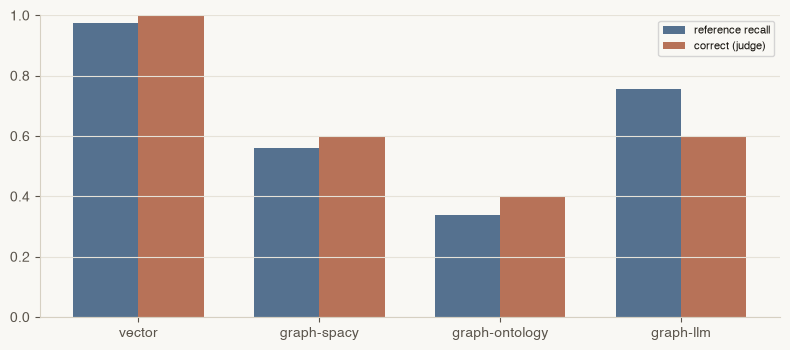

In [10]:
import matplotlib.pyplot as plt
from helpers.brand import matplotlib_style

plt.rcParams.update(matplotlib_style())
names = list(EVALS)
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - 0.18, [EVALS[n]["recall"] for n in names], 0.36, label="reference recall")
ax.bar(x + 0.18, [EVALS[n]["correct"] for n in names], 0.36, label="correct (judge)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

You should see a table with one row per condition and a bar chart of recall and correctness. Stop here if the vector row has zero correctness: the judge is failing every answer, so print one judge reply before you read anything into the graph rows.

### ❓ Question
Which condition won on correctness, and did the graph earn its build cost on this corpus? If the vector baseline won, say what question shape would change that.

Answer:

## Task 7 of 7 — Save the graph and the scores

Save the best graph as nodes and edges, and the comparison as two score blocks: the graph's and the vector baseline's. The graph is the one later notebooks can walk; the scores are what the release decision reads when someone proposes GraphRAG for the prototype.

In [11]:
graph_names = [n for n in EVALS if n.startswith("graph-")]
best_graph = max(graph_names, key=lambda n: (EVALS[n]["correct"], EVALS[n]["recall"]))
kg = GRAPHS[best_graph.removeprefix("graph-")]
GRAPH = {"builder": best_graph.removeprefix("graph-"),
         "nodes": [{"id": n, "type": d.get("type", "")} for n, d in kg.g.nodes(data=True)],
         "edges": [{"source": u, "target": v, "relation": d["relation"], "page": d.get("source", "")}
                   for u, v, d in kg.g.edges(data=True)]}
ws.save("graph", GRAPH)

scores = {n: {k: round(v, 3) for k, v in e.items() if k in ("recall", "correct", "n")} for n, e in EVALS.items()}
ws.save("graph_eval", {"graph": {**scores[best_graph], "builder": best_graph}, "vector": scores["vector"],
                       "all": scores, "eval_cases": len(EVAL), "model": LLM_MODEL})
print(f"best graph: {best_graph} with {len(GRAPH['nodes'])} nodes and {len(GRAPH['edges'])} edges")

✅ wrote graph → workspace/retrieval/graph.json (3 rows)
✅ wrote graph_eval → workspace/retrieval/graph_eval.json (5 rows)
best graph: graph-llm with 259 nodes and 236 edges


You should see two ✅ lines and the best builder with its node and edge counts. Stop here if the best graph has fewer than twenty nodes: the extractors found almost nothing, and a graph that small cannot beat anything.

## Your turn

Extend the ontology. Add one entity type your product cares about with five phrases, and one relation that connects it to an existing type. Rebuild the ontology graph and rerun the evaluation for that condition only. Explain to a teammate whether precision by design beat the model on the questions it now covers.

In [12]:
# Shape: ONTOLOGY["YourType"] = [...phrases...]; _REL["YourType"] = "YOUR_RELATION"; then rebuild and re-score.
ONTOLOGY_EXTRA: dict[str, list[str]] = {}
if ONTOLOGY_EXTRA:
    ONTOLOGY.update(ONTOLOGY_EXTRA)
    for etype in ONTOLOGY_EXTRA:
        _REL.setdefault(etype, "MENTIONS")
    GRAPHS["ontology"] = KnowledgeGraph(ontology_triples(SECTIONS) + STRUCTURAL, SECTIONS)
    EVALS["graph-ontology"] = evaluate("graph-ontology", GraphRAG(GRAPHS["ontology"]))
    print({k: round(v, 2) for k, v in EVALS["graph-ontology"].items() if k != "rows"})
else:
    print("add a type to ONTOLOGY_EXTRA and rerun")

add a type to ONTOLOGY_EXTRA and rerun


# Grow


## From prototype to production

| What we built | Production equivalent |
|---|---|
| Three graphs in a networkx object in the kernel | A graph database with persistence, a query language, and access control |
| String match plus embedding nearest-name entity linking | Entity resolution with aliases, disambiguation, and a curated vocabulary |
| Rebuilt from scratch each run | Incremental updates as pages and transcripts change |
| A handful of eval cases with a term-recall proxy | Versioned multi-hop eval suites with gold sources and confidence intervals |
| One corpus, one afternoon | Build-cost accounting per corpus: is the graph worth maintaining here? |

## Responsible controls

- Graph extraction reviewed on a sample before it feeds answers.
- A rebuild cost measured and scheduled.
- Entity merges logged so a wrong merge can be undone.


## Grow further

- Community summaries: run a community detection over the model graph, summarize each community with one call, and answer a "what are the themes" question the local subgraph cannot.
- Fuse instead of choosing: put graph facts and baseline chunks in one context and score the union against both.
- Rerank the graph's source passages with the same cross-encoder and see whether the graph's recall plus the reranker's precision beats either alone.